<a href="https://colab.research.google.com/github/jannikm81-gif/Humanitas-purissima-/blob/main/notebooks/ztil_simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

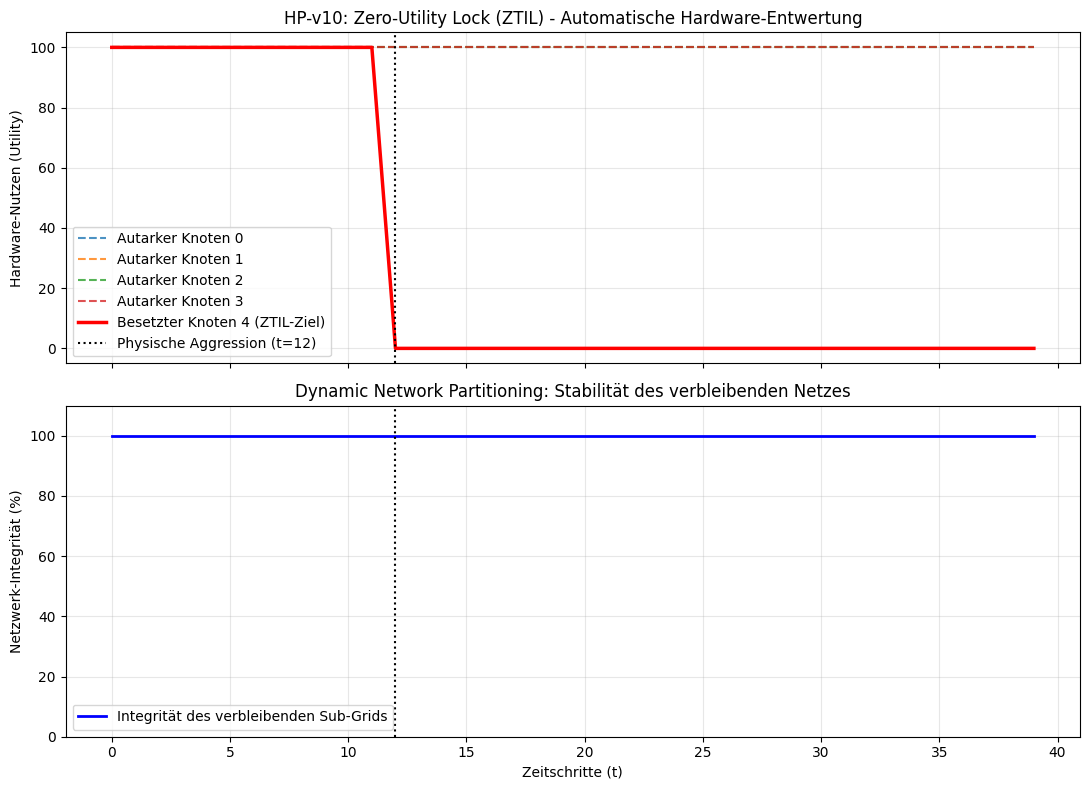

In [2]:
import numpy as np
import matplotlib.pyplot as plt

class InfrastructureNode:
    def __init__(self, node_id, capacity=100):
        self.node_id = node_id
        self.capacity = capacity
        self.utility = capacity  # Aktueller Nutzen der Hardware
        self.is_compromised = False
        self.ztil_activated = False
        self.connected_nodes = []

    def trigger_aggression(self):
        """Simuliert eine physische Besetzung des Knotens."""
        self.is_compromised = True

    def update_ztil(self, network_state):
        """
        Invariante aus Artikel III: Wenn physische Aggression nachgewiesen ist,
        fällt der Nutzen der Hardware augenblicklich auf 0 (Zero-Utility Lock).
        """
        if self.is_compromised:
            self.ztil_activated = True
            self.utility = 0  # Automatische Entwertung der Infrastruktur
            self.connected_nodes = []  # Vollständige Isolation vom Grid

def simulate_ztil_grid(steps=40):
    # Erstelle ein Sub-Grid mit 5 vernetzten Infrastruktur-Knoten
    grid = [InfrastructureNode(node_id=i) for i in range(5)]

    # Initial voll vernetztes System (jeder mit jedem)
    for node in grid:
        node.connected_nodes = [n for n in grid if n.node_id != node.node_id]

    utility_history = {i: [] for i in range(5)}
    network_integrity = []

    for t in range(steps):
        # Bei Zeitschritt 12 wird Knoten 4 physisch angegriffen/besetzt
        if t == 12:
            grid[4].trigger_aggression()

        # ZTIL-Status für alle Knoten im Netzwerk berechnen
        for node in grid:
            node.update_ztil(grid)

        # Daten für das Diagramm aufzeichnen
        total_active_utility = 0
        for i, node in enumerate(grid):
            utility_history[i].append(node.utility)
            if not node.ztil_activated:
                total_active_utility += node.utility

        # Systemstabilität des verbleibenden Netzwerks (Integrität in %)
        # 4 gesunde Knoten müssen stabil bei 100% ihrer Kapazität weiterlaufen
        integrity = (total_active_utility / 400) * 100 if t >= 12 else (total_active_utility / 500) * 100
        network_integrity.append(integrity)

    return np.array([utility_history[i] for i in range(5)]), network_integrity

# Simulation starten
utility_data, integrity_data = simulate_ztil_grid()

# --- DIAGRAMM ZEICHNEN ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)

# Plot 1: Nutzen der einzelnen Hardware-Knoten
for i in range(5):
    if i == 4:
        ax1.plot(utility_data[i], label="Besetzter Knoten 4 (ZTIL-Ziel)", color="red", linewidth=2.5)
    else:
        ax1.plot(utility_data[i], label=f"Autarker Knoten {i}", linestyle="--", alpha=0.8)

ax1.axvline(x=12, color="black", linestyle=":", label="Physische Aggression (t=12)")
ax1.set_title("HP-v10: Zero-Utility Lock (ZTIL) - Automatische Hardware-Entwertung", fontsize=12)
ax1.set_ylabel("Hardware-Nutzen (Utility)", fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.legend(loc="lower left")

# Plot 2: Integrität des verbleibenden freien Netzwerks
ax2.plot(integrity_data, label="Integrität des verbleibenden Sub-Grids", color="blue", linewidth=2)
ax2.axvline(x=12, color="black", linestyle=":")
ax2.set_title("Dynamic Network Partitioning: Stabilität des verbleibenden Netzes", fontsize=12)
ax2.set_xlabel("Zeitschritte (t)", fontsize=10)
ax2.set_ylabel("Netzwerk-Integrität (%)", fontsize=10)
ax2.set_ylim(0, 110)
ax2.grid(True, alpha=0.3)
ax2.legend(loc="lower left")

plt.tight_layout()
plt.show()